# FER2013 dataset

Available on [Kaggle](kaggle.com/dmsambare/fer2013)

In [12]:
import kagglehub
from datasets import FER2013Dataset
import matplotlib.pyplot as plt
import random
import torch

emotions = ['happy','angry','sad','disgust','fear','neutral', 'surprise']

In [2]:
PATH = '/home/lucaspaulogoncalves/data'

kagglehub.dataset_download("msambare/fer2013", output_dir=PATH)

'/home/lucaspaulogoncalves/data'

In [3]:
train_ds = FER2013Dataset(PATH, 'train')
test_ds = FER2013Dataset(PATH, 'test')

In [76]:
print(len(train_ds), len(test_ds), len(train_ds) + len(test_ds))

28709 7178 35887


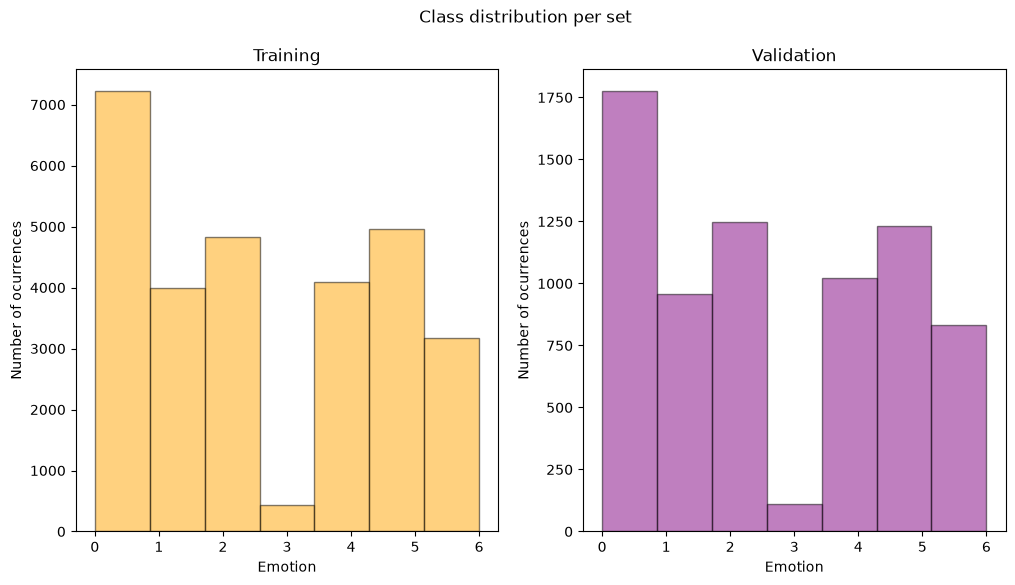

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

plt.suptitle('Class distribution per set')

ax[0].hist(train_ds[:][1], bins=7, color='orange', edgecolor='black', alpha=0.5)
ax[0].set_title('Training')
ax[0].set_xlabel('Emotion')
ax[0].set_ylabel('Number of ocurrences')

ax[1].hist(test_ds[:][1], bins=7, color='purple', edgecolor='black', alpha=0.5)
ax[1].set_title('Validation')
ax[1].set_xlabel('Emotion')
ax[1].set_ylabel('Number of ocurrences')

plt.show()


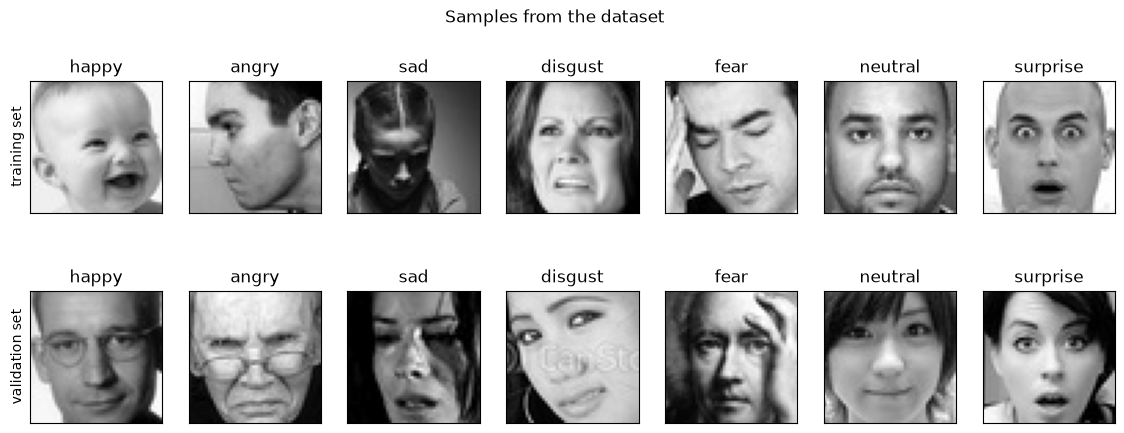

In [80]:
dss = [('training set', train_ds), ('validation set', test_ds)]

fig, ax = plt.subplots(2, 7, figsize = (14, 5))
plt.suptitle('Samples from the dataset')

for i in range(2):

    set_counts = torch.bincount(dss[i][1].y).tolist()

    class_limits = [0]

    idx = []

    for j in range(7):
        class_limits.append(sum(set_counts[0:j+1]))

    for j in range(1, 8):
        idx.append(random.randint(class_limits[j-1], class_limits[j]-1))

    for j in range(7):
        ax[i][j].imshow(dss[i][1] [idx[j]][0][0], cmap='gray')
        ax[i][j].set_title(emotions[j])
        ax[i][j].set_xticks([])
        ax[i][j].set_yticks([])

    ax[i][0].set_ylabel(dss[i][0], rotation=90)

plt.show()
